# CH-5 Classification- Model Training & Evaluation

## k-Nearest Neighbors Algorithm

Euclidian distance =root((f11-f12)^2 +(f21-f22)^2)

- Data Preparation
- choose k
- compute distance
- identify neighbors
- make prediction

In [2]:
import pandas as pd
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
x=df.iloc[:,0:8]
y=df["Outcome"]
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [7]:
x.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1) 
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [11]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=15)
model.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


In [13]:
#OR
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=15)
model=nn.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


In [16]:
diff=pd.DataFrame({'Actual':y_test,'Predicted':prediction})
diff

,Actual,Predicted
285,0,1
101,0,0
581,0,0
352,0,0
726,0,0
...,...,...
563,0,0
318,0,0
154,1,1
684,0,0


In [17]:
diff.to_csv('diabetes_data.csv')

In [18]:
diff.to_excel('diabetes_data.xlsx')

In [20]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)

[[89 10]
 [23 32]]


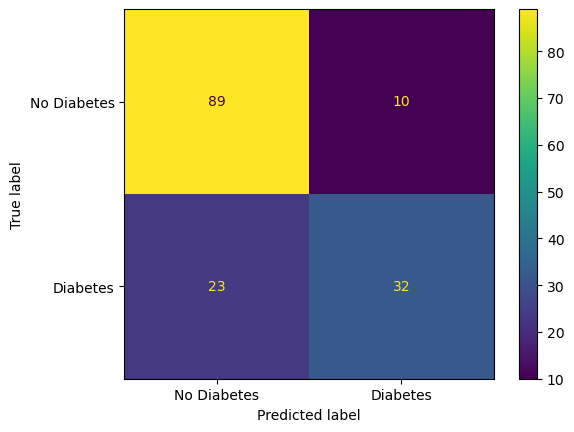

In [22]:
import matplotlib.pyplot as plt
from sklearn import metrics
cm_disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=['No Diabetes','Diabetes'])
cm_disp.plot()
plt.show()

- 89,0-0, True Negative(TN)
- 10,0-1 False Positive(FP)
- 23,1-0 False Negative(FN)
- 32-1-1 True Positive(TP)

In [25]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

89 10 23 32


In [26]:
model_accuracy = (TP+ TN)/(TP+FP+FN+TN)
print("Accuracy score:",model_accuracy)

Accuracy score: 0.7857142857142857


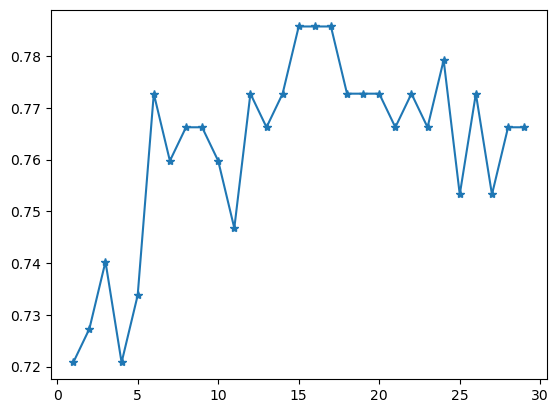

In [46]:
from sklearn.neighbors import KNeighborsClassifier
acc=[]
for i in range(1,30):
    nn=KNeighborsClassifier(n_neighbors=i)
    model=nn.fit(x_train,y_train)
    predicton=model.predict(x_test)
    cm= confusion_matrix(y_test,predicton)
    TN=cm[0][0]
    FP=cm[0][1]
    FN=cm[1][0]
    TP=cm[1][1]
    model_accuracy = (TP+ TN)/(TP+FP+FN+TN)
    acc.append(model_accuracy)
plt.plot(range(1,30),acc,marker="*")
plt.show()

In [47]:
from sklearn.metrics import accuracy_score
print("accuracy: ",accuracy_score(y_test,prediction))

accuracy:  0.7857142857142857


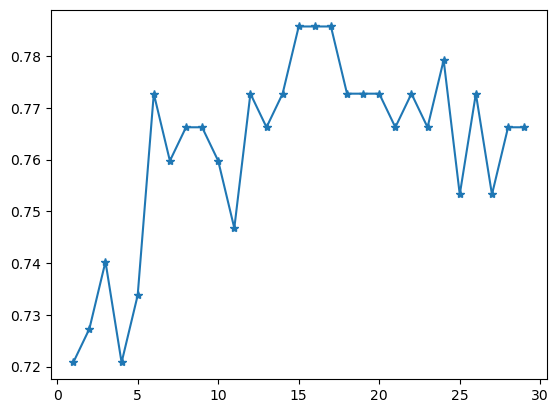

In [48]:
from sklearn.neighbors import KNeighborsClassifier
acc=[]
for i in range(1,30):
    nn=KNeighborsClassifier(n_neighbors=i)
    model=nn.fit(x_train,y_train)
    predicton=model.predict(x_test)
    acc.append(accuracy_score(y_test,predicton))
    
plt.plot(range(1,30),acc,marker="*")
plt.show()

## Error Rate

In [49]:
error_rate = 1-(accuracy_score(y_test,prediction))
print("Error Rate: ",error_rate)

Error Rate:  0.2142857142857143


In [50]:
error_rate = (FP+ FN)/(TP+FP+FN+TN)
print("Error Rate: ",error_rate)

Error Rate:  0.23376623376623376


## Sensitivity

In [51]:
sensitivity=(TP)/(TP+FN)
print("Sensitivity: ",sensitivity)

Sensitivity:  0.5272727272727272


In [53]:
from sklearn.metrics import recall_score
print("Sensitivity: ",recall_score(y_test,predicton))


Sensitivity:  0.5272727272727272


## Specificity

In [55]:
print("Specificity: ",(TN)/(TN+FP))

Specificity:  0.898989898989899


In [56]:
from sklearn.metrics import recall_score
print("Specificity: ",recall_score(y_test,predicton,pos_label=0))

Specificity:  0.898989898989899


## Precision Score

In [61]:
print("Precison Score: ",(TP)/(TP+FP))

Precison Score:  0.7435897435897436


In [62]:
from sklearn.metrics import precision_score
print("Precision Score:",precision_score(y_test,prediction))

Precision Score: 0.7619047619047619


In [ ]:
df=pd.read_csv("tshirt.csv")
df